In [59]:
import matplotlib.pyplot as plt

def read_conllu(filename):
    result = [ ]
    for line in open(filename, "r"):
        line = line.strip()
        if not line:
            continue

        parts = line.split()
        result.append((parts[1].lower(), parts[3]))

    return result

In [60]:
corpus = read_conllu('en_goldconllu.sec')

# Task 1

### We want to plot a line graph showing the frequencies  of the 100 most frequent words.  This should look like a zipfian distribution    

First, let's find the frequencies of each word. Build a dict where the keys are words in the corpus, and the values are those words' frequencies.

In [61]:
word_frequencies = {}
    
for word, pos in corpus:
    if word not in word_frequencies:
        word_frequencies[word] = 1
    else:
        word_frequencies[word] += 1

Next, let's sort all the words by frequency. This is done for you, but pay attention to how.  Look up the documentation for list.sort to understand what we are doing here.

In [62]:
words = list(word_frequencies.keys())
def key_func(word):
    return -word_frequencies[word]

words.sort(key=key_func)

Now let's get the most frequent 100 words, and there frequencies. 
- top_words should be a list of the 100 most frequent words.
- top_frequencies should be a 100-element list of those words' frequencies.


In [63]:
top_words = words[:100]
top_frequencies = [word_frequencies[word] for word in top_words]

Now plot the line graph -- look up matplotlib's documentation for this.

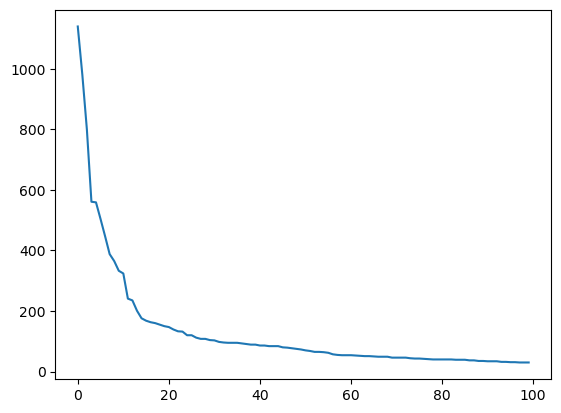

In [64]:
plt.plot(top_frequencies)
plt.show()

# Task 2

###  We want to show a pie chart of the different parts of speech and their frequencies as percentages.  All Parts of speech less than 2% of the total should be in a single "Other" category. Parts of speech should be ordered around the chart from most to least frequent, with "Other" coming after the least frequent


First, let's find the frequencies of each POS tag. Build a dict where the keys are POS tags in the corpus, and the values are those POS's frequencies.


In [65]:
pos_frequencies = {}
    
for word, pos in corpus:
    if pos not in pos_frequencies:
        pos_frequencies[pos] = 1
    else:
        pos_frequencies[pos] += 1

Now, let's combine all part of speech with <2% of the total into an "Other" category;

We'll store these new frequencies in a new dict called fixed_pos_frequencies that has "Other" as a key.  This new dict should look the same as pos_frequencies, with the same keys and values for common POS tags, except that all rare POS tags are counted under the key "Other".

In [66]:
fixed_pos_frequencies = {"Other": 0}

n_tokens = len(corpus)
all_freqs = sum(pos_frequencies.values())
threshold = 0.02 * all_freqs
for pos, freq in pos_frequencies.items():
    if freq < threshold:
        fixed_pos_frequencies["Other"] += freq
    elif:
        fixed_pos_frequencies[pos] = freq
    else:
        fixed_pos_frequencies[pos] += freq

SyntaxError: invalid syntax (3269321266.py, line 9)

The rest is up to you.  First, look up how to draw a pie chart using matplotlib. How will you need to format your data in order to use matplotlib's function.  Format your data in the proper way, and draw the pie chart.  Don't forget our requirements for the order of the wedges.

TypeError: unhashable type: 'numpy.ndarray'

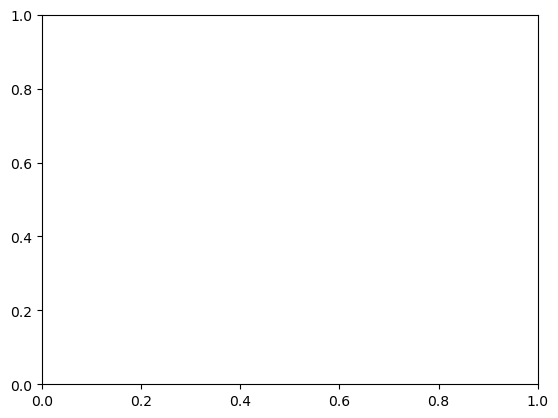

In [ ]:
plt.figure(figsize=(10, 10))
fig, ax = plt.subplots()
ax.pie(fixed_pos_frequencies.values(), labels=fixed_pos_frequencies.keys())
plt.show()